Crimes by District OPENDOSM prediction using Random Forest Regressor

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("crime_district.csv")

df.head()

,state,district,category,type,date,crimes
0,Malaysia,All,assault,all,2016-01-01,22327
1,Malaysia,All,assault,all,2017-01-01,21366
2,Malaysia,All,assault,all,2018-01-01,16902
3,Malaysia,All,assault,all,2019-01-01,16489
4,Malaysia,All,assault,all,2020-01-01,13279


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19152 entries, 0 to 19151
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   state     19152 non-null  str  
 1   district  19152 non-null  str  
 2   category  19152 non-null  str  
 3   type      19152 non-null  str  
 4   date      19152 non-null  str  
 5   crimes    19152 non-null  int64
dtypes: int64(1), str(5)
memory usage: 897.9 KB


In [3]:
df.describe()

,crimes
count,19152.000000
mean,189.728018
std,1590.813293
min,0.000000
25%,1.000000
50%,12.000000
75%,66.000000
max,90028.000000


In [4]:
df.describe()

,crimes
count,19152.000000
mean,189.728018
std,1590.813293
min,0.000000
25%,1.000000
50%,12.000000
75%,66.000000
max,90028.000000


Data Cleaning

In [4]:
df = df.dropna()

df.columns = df.columns.str.lower().str.replace(" ", "_")

Sanitizekan Time Series Property

In [5]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

Encoding

Crimes by District

In [6]:
df.groupby('district')['crimes'].sum().sort_values(ascending=False)

district
All               2421988
Petaling Jaya       46156
Dang Wangi          39960
Kajang              38500
Gombak              38116
                   ...   
Dalat                 308
Kanowit               254
Pengkalan Hulu        230
Julau                 174
Song                  142
Name: crimes, Length: 160, dtype: int64

Crimes Over Time

<Axes: xlabel='year'>

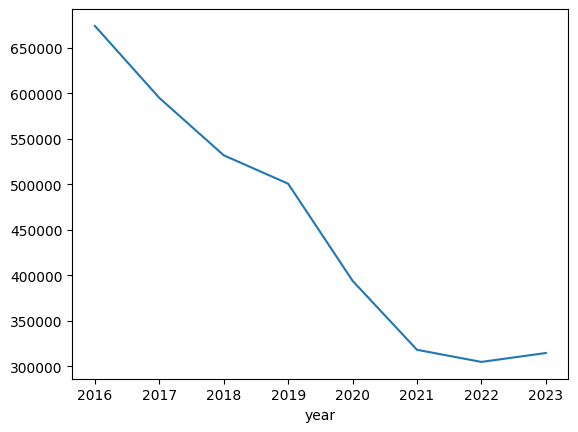

In [7]:
df.groupby('year')['crimes'].sum().plot()

Crimes by Category

In [8]:
df['category'].unique()

<StringArray>
['assault', 'property']
Length: 2, dtype: str

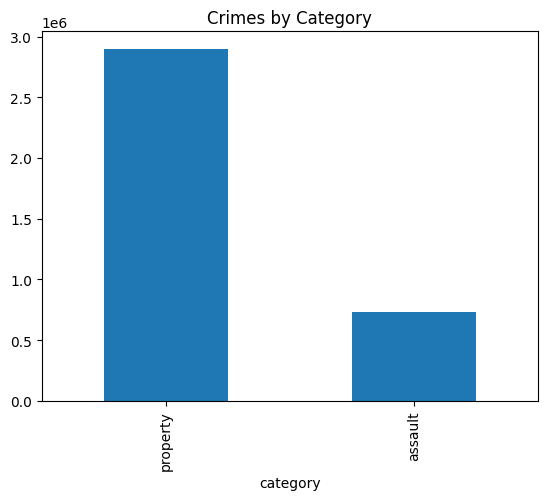

In [12]:
category_crime = df.groupby('category')['crimes'].sum().sort_values(ascending=False)

category_crime.plot(kind='bar')
plt.title("Crimes by Category")
plt.show()

ML Preprocessing

In [14]:
df_encoded = pd.get_dummies(df, columns=['state', 'district', 'category', 'type'])

In [15]:
X = df_encoded.drop(['crimes', 'date'], axis=1)
y = df_encoded['crimes']

Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

preds = model.predict(X_test)

Evaluation

In [17]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, preds)

32.18708170190551

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R^2: {r2}")

MAE: 32.18708170190551
RMSE: 213.56990500173114
R^2: 0.9322297561927704


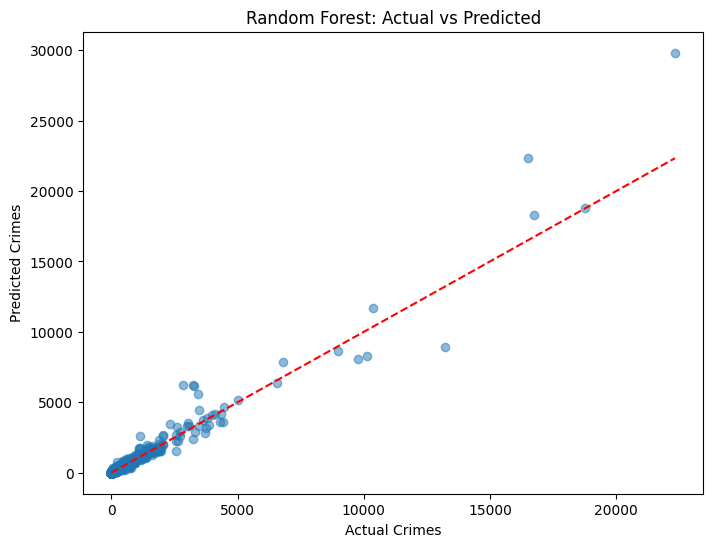

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')  
plt.xlabel("Actual Crimes")
plt.ylabel("Predicted Crimes")
plt.title("Random Forest: Actual vs Predicted")
plt.show()